In [1]:
import pandas as pd
import numpy as np 
import torch
import os
import glob
import matplotlib.pyplot as plt 
from PIL import Image

Class 0: 200 ảnh
Class 1: 200 ảnh
Class 2: 200 ảnh
Class 3: 200 ảnh
Class 4: 200 ảnh
Class 5: 200 ảnh
Class 6: 200 ảnh
Class 7: 200 ảnh
Class 8: 200 ảnh
Class 9: 200 ảnh


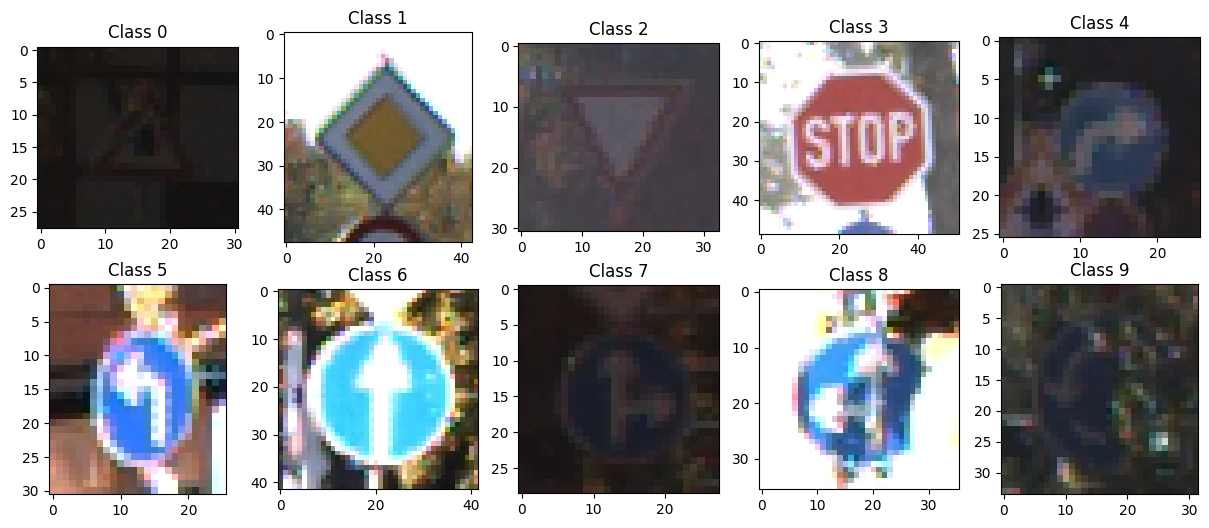

In [2]:
TRAIN_DIR ='../data/train'
TEST_DIR = '../data/test'

for cls in sorted(os.listdir(TRAIN_DIR)):        #dem so anh moi class
    n=len(os.listdir(os.path.join(TRAIN_DIR,cls)))
    print(f"Class {cls}: {n} ảnh")
# Xem thử một vài ảnh
fig, axes = plt.subplots(2, 5, figsize=(15, 6))
for i, ax in enumerate(axes.flat):
    img_path = glob.glob(f"{TRAIN_DIR}/{i}/*.png")[0]
    ax.imshow(Image.open(img_path))
    ax.set_title(f"Class {i}")
plt.show()


In [ ]:
import tensorflow as tf

def build_model():
    model = tf.keras.Sequential([
        # Block 1
        tf.keras.layers.Conv2D(32, 3, padding='same', activation='relu', input_shape=(32,32,3), kernel_regularizer=tf.keras.regularizers.l2(1e-4)),
        tf.keras.layers.BatchNormalization(),
        tf.keras.layers.MaxPooling2D(2),      # Output: 16x16
        
        # Block 2
        tf.keras.layers.Conv2D(64, 3, padding='same', activation='relu', kernel_regularizer=tf.keras.regularizers.l2(1e-4)),
        tf.keras.layers.BatchNormalization(),
        tf.keras.layers.MaxPooling2D(2),      # Output: 8x8
        
        # Block 3 
        tf.keras.layers.Conv2D(64, 3, padding='same', activation='relu', kernel_regularizer=tf.keras.regularizers.l2(1e-4)),
        tf.keras.layers.BatchNormalization(),
        tf.keras.layers.MaxPooling2D(2),      # Output: 4x4
        
        # Sử dụng Flatten 
        tf.keras.layers.Flatten(),            # Output: 4 * 4 * 64 = 1024
        
        # Lớp Dense trung gian (Giảm từ 128 xuống 64 để giữ limit param)
        tf.keras.layers.Dense(64, activation='relu', kernel_regularizer=tf.keras.regularizers.l2(1e-4)),
        tf.keras.layers.BatchNormalization(),
        tf.keras.layers.Dropout(0.5),         # Giữ nguyên Dropout 0.5 để chống overfitting
        
        # Lớp phân loại cuối cùng (10 labels)
        tf.keras.layers.Dense(10, activation='softmax')
    ])
    
    return model


model = build_model()
model.summary()   # ← kiểm tra tổng params < 200.000


d:\dut_ai\AIO_Code\venv\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 32, 32, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 16, 16, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 8, 8, 64)       │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 8, 8, 64)       │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 4, 4, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │        65,600 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 123,466 (482.29 KB)

 Trainable params: 123,018 (480.54 KB)

 Non-trainable params: 448 (1.75 KB)

In [4]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# 1. Datagen cho Train (có Augmentation)
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=15,
    width_shift_range=0.15,
    height_shift_range=0.15,
    zoom_range=0.15,          
    shear_range=0.1,          
    brightness_range=[0.8, 1.2],  
    horizontal_flip=False,   
    validation_split=0.2
)

# 2. Datagen cho Validation (KHÔNG Augmentation, chỉ Scale)
val_datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2
)

# 3. Tạo Train Generator
train_gen = train_datagen.flow_from_directory(
    TRAIN_DIR,
    target_size=(32, 32),
    batch_size=32,
    class_mode='sparse',
    subset='training',
    seed=42  # BẮT BUỘC có seed=42 để chia split chuẩn
)

# 4. Tạo Validation Generator
val_gen = val_datagen.flow_from_directory(
    TRAIN_DIR,
    target_size=(32, 32),
    batch_size=32,
    class_mode='sparse',
    subset='validation',
    seed=42  # BẮT BUỘC có seed=42 để chia split chuẩn
)

model.compile(
    optimizer=tf.keras.optimizers.Adam(1e-3),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

callbacks = [
    tf.keras.callbacks.EarlyStopping(patience=10, restore_best_weights=True),
    tf.keras.callbacks.ReduceLROnPlateau(factor=0.5, patience=5),
    tf.keras.callbacks.ModelCheckpoint("best_model.h5", save_best_only=True)
]

history = model.fit(train_gen, validation_data=val_gen, epochs=100, callbacks=callbacks)




Found 1600 images belonging to 10 classes.
Found 400 images belonging to 10 classes.
Epoch 1/100
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 63ms/step - accuracy: 0.1941 - loss: 2.8641

50/50 ━━━━━━━━━━━━━━━━━━━━ 6s 77ms/step - accuracy: 0.2650 - loss: 2.4452 - val_accuracy: 0.1325 - val_loss: 2.3321 - learning_rate: 0.0010
Epoch 2/100
50/50 ━━━━━━━━━━━━━━━━━━━━ 3s 60ms/step - accuracy: 0.4225 - loss: 1.7056 - val_accuracy: 0.1375 - val_loss: 2.3799 - learning_rate: 0.0010
Epoch 3/100
50/50 ━━━━━━━━━━━━━━━━━━━━ 3s 70ms/step - accuracy: 0.5663 - loss: 1.2759 - val_accuracy: 0.1275 - val_loss: 2.4283 - learning_rate: 0.0010
Epoch 4/100
50/50 ━━━━━━━━━━━━━━━━━━━━ 4s 71ms/step - accuracy: 0.7000 - loss: 0.9269 - val_accuracy: 0.1500 - val_loss: 2.4835 - learning_rate: 0.0010
Epoch 5/100
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 69ms/step - accuracy: 0.7314 - loss: 0.7801

50/50 ━━━━━━━━━━━━━━━━━━━━ 4s 76ms/step - accuracy: 0.7681 - loss: 0.7067 - val_accuracy: 0.2600 - val_loss: 2.1681 - learning_rate: 0.0010
Epoch 6/100
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 63ms/step - accuracy: 0.8349 - loss: 0.5847

50/50 ━━━━━━━━━━━━━━━━━━━━ 4s 71ms/step - accuracy: 0.8381 - loss: 0.5459 - val_accuracy: 0.2650 - val_loss: 2.1089 - learning_rate: 0.0010
Epoch 7/100
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 70ms/step - accuracy: 0.8770 - loss: 0.4503

50/50 ━━━━━━━━━━━━━━━━━━━━ 4s 85ms/step - accuracy: 0.8863 - loss: 0.4327 - val_accuracy: 0.3475 - val_loss: 1.9223 - learning_rate: 0.0010
Epoch 8/100
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 116ms/step - accuracy: 0.8792 - loss: 0.4031

...

50/50 ━━━━━━━━━━━━━━━━━━━━ 3s 68ms/step - accuracy: 0.9806 - loss: 0.1256 - val_accuracy: 0.9075 - val_loss: 0.3571 - learning_rate: 0.0010
Epoch 20/100
50/50 ━━━━━━━━━━━━━━━━━━━━ 4s 70ms/step - accuracy: 0.9806 - loss: 0.1060 - val_accuracy: 0.8550 - val_loss: 0.4815 - learning_rate: 0.0010
Epoch 21/100
50/50 ━━━━━━━━━━━━━━━━━━━━ 3s 69ms/step - accuracy: 0.9812 - loss: 0.1033 - val_accuracy: 0.8950 - val_loss: 0.4222 - learning_rate: 0.0010
Epoch 22/100
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 59ms/step - accuracy: 0.9797 - loss: 0.1001

50/50 ━━━━━━━━━━━━━━━━━━━━ 3s 65ms/step - accuracy: 0.9819 - loss: 0.0972 - val_accuracy: 0.9125 - val_loss: 0.3551 - learning_rate: 0.0010
Epoch 23/100
50/50 ━━━━━━━━━━━━━━━━━━━━ 3s 69ms/step - accuracy: 0.9769 - loss: 0.1198 - val_accuracy: 0.8650 - val_loss: 0.4881 - learning_rate: 0.0010
Epoch 24/100
50/50 ━━━━━━━━━━━━━━━━━━━━ 3s 65ms/step - accuracy: 0.9887 - loss: 0.0786 - val_accuracy: 0.8700 - val_loss: 0.4292 - learning_rate: 0.0010
Epoch 25/100
50/50 ━━━━━━━━━━━━━━━━━━━━ 3s 65ms/step - accuracy: 0.9850 - loss: 0.0838 - val_accuracy: 0.8525 - val_loss: 0.6091 - learning_rate: 0.0010
Epoch 26/100
50/50 ━━━━━━━━━━━━━━━━━━━━ 3s 63ms/step - accuracy: 0.9900 - loss: 0.0732 - val_accuracy: 0.8875 - val_loss: 0.4014 - learning_rate: 0.0010
Epoch 27/100
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 58ms/step - accuracy: 0.9821 - loss: 0.0827

50/50 ━━━━━━━━━━━━━━━━━━━━ 3s 66ms/step - accuracy: 0.9875 - loss: 0.0784 - val_accuracy: 0.9025 - val_loss: 0.3452 - learning_rate: 0.0010
Epoch 28/100
50/50 ━━━━━━━━━━━━━━━━━━━━ 4s 70ms/step - accuracy: 0.9894 - loss: 0.0729 - val_accuracy: 0.8850 - val_loss: 0.4426 - learning_rate: 0.0010
Epoch 29/100
50/50 ━━━━━━━━━━━━━━━━━━━━ 4s 70ms/step - accuracy: 0.9925 - loss: 0.0699 - val_accuracy: 0.8800 - val_loss: 0.3752 - learning_rate: 0.0010
Epoch 30/100
50/50 ━━━━━━━━━━━━━━━━━━━━ 3s 64ms/step - accuracy: 0.9887 - loss: 0.0695 - val_accuracy: 0.9200 - val_loss: 0.4153 - learning_rate: 0.0010
Epoch 31/100
50/50 ━━━━━━━━━━━━━━━━━━━━ 3s 63ms/step - accuracy: 0.9956 - loss: 0.0607 - val_accuracy: 0.8950 - val_loss: 0.4062 - learning_rate: 0.0010
Epoch 32/100
50/50 ━━━━━━━━━━━━━━━━━━━━ 3s 63ms/step - accuracy: 0.9831 - loss: 0.0891 - val_accuracy: 0.8100 - val_loss: 0.6678 - learning_rate: 0.0010
Epoch 33/100
50/50 ━━━━━━━━━━━━━━━━━━━━ 3s 64ms/step - accuracy: 0.9875 - loss: 0.0769 - val_ac

50/50 ━━━━━━━━━━━━━━━━━━━━ 3s 65ms/step - accuracy: 0.9925 - loss: 0.0585 - val_accuracy: 0.9225 - val_loss: 0.3268 - learning_rate: 5.0000e-04
Epoch 35/100
50/50 ━━━━━━━━━━━━━━━━━━━━ 4s 71ms/step - accuracy: 0.9931 - loss: 0.0615 - val_accuracy: 0.8825 - val_loss: 0.5347 - learning_rate: 5.0000e-04
Epoch 36/100
50/50 ━━━━━━━━━━━━━━━━━━━━ 3s 66ms/step - accuracy: 0.9944 - loss: 0.0506 - val_accuracy: 0.8925 - val_loss: 0.4337 - learning_rate: 5.0000e-04
Epoch 37/100
50/50 ━━━━━━━━━━━━━━━━━━━━ 3s 63ms/step - accuracy: 0.9987 - loss: 0.0441 - val_accuracy: 0.8950 - val_loss: 0.3639 - learning_rate: 5.0000e-04
Epoch 38/100
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 61ms/step - accuracy: 0.9950 - loss: 0.0488

50/50 ━━━━━━━━━━━━━━━━━━━━ 3s 69ms/step - accuracy: 0.9962 - loss: 0.0485 - val_accuracy: 0.9275 - val_loss: 0.2655 - learning_rate: 5.0000e-04
Epoch 39/100
50/50 ━━━━━━━━━━━━━━━━━━━━ 4s 70ms/step - accuracy: 0.9969 - loss: 0.0458 - val_accuracy: 0.9225 - val_loss: 0.2893 - learning_rate: 5.0000e-04
Epoch 40/100
50/50 ━━━━━━━━━━━━━━━━━━━━ 5s 60ms/step - accuracy: 0.9981 - loss: 0.0465 - val_accuracy: 0.9150 - val_loss: 0.3359 - learning_rate: 5.0000e-04
Epoch 41/100
50/50 ━━━━━━━━━━━━━━━━━━━━ 3s 64ms/step - accuracy: 0.9975 - loss: 0.0444 - val_accuracy: 0.9125 - val_loss: 0.2891 - learning_rate: 5.0000e-04
Epoch 42/100
50/50 ━━━━━━━━━━━━━━━━━━━━ 3s 63ms/step - accuracy: 0.9931 - loss: 0.0489 - val_accuracy: 0.9125 - val_loss: 0.3104 - learning_rate: 5.0000e-04
Epoch 43/100
50/50 ━━━━━━━━━━━━━━━━━━━━ 3s 65ms/step - accuracy: 0.9912 - loss: 0.0517 - val_accuracy: 0.9000 - val_loss: 0.3772 - learning_rate: 5.0000e-04
Epoch 44/100
50/50 ━━━━━━━━━━━━━━━━━━━━ 3s 63ms/step - accuracy: 0.9969

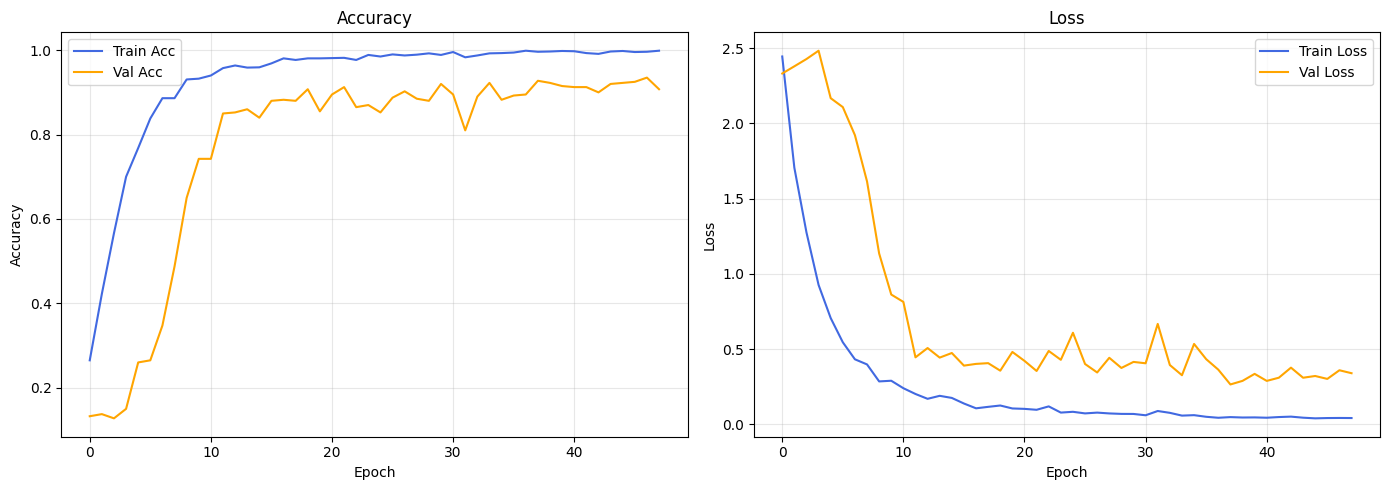

Best val_accuracy: 0.9350 tại Epoch 47


In [5]:
import matplotlib.pyplot as plt

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Accuracy
ax1.plot(history.history['accuracy'],     label='Train Acc', color='royalblue')
ax1.plot(history.history['val_accuracy'], label='Val Acc',   color='orange')
ax1.set_title('Accuracy')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Accuracy')
ax1.legend()
ax1.grid(True, alpha=0.3)

# Loss
ax2.plot(history.history['loss'],     label='Train Loss', color='royalblue')
ax2.plot(history.history['val_loss'], label='Val Loss',   color='orange')
ax2.set_title('Loss')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Loss')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# In kết quả tốt nhất
best_epoch = history.history['val_accuracy'].index(max(history.history['val_accuracy'])) + 1
best_val   = max(history.history['val_accuracy'])
print(f"Best val_accuracy: {best_val:.4f} tại Epoch {best_epoch}")


In [6]:
from tensorflow.keras.models import load_model
# Load best model đã save
best_model = load_model('best_model.h5')
# Tạo representative dataset cho int8 quantization
def representative_dataset():
    datagen = tf.keras.preprocessing.image.ImageDataGenerator(rescale=1./255)
    gen = datagen.flow_from_directory(
        TRAIN_DIR,
        target_size=(32, 32),
        batch_size=1,
        shuffle=True
    )
    for i in range(200):   # dùng 200 ảnh để calibrate
        img, _ = next(gen)
        yield [img.astype(np.float32)]
# Convert sang TFLite int8
converter = tf.lite.TFLiteConverter.from_keras_model(best_model)
converter.optimizations = [tf.lite.Optimize.DEFAULT]
converter.representative_dataset = representative_dataset
converter.target_spec.supported_ops = [tf.lite.OpsSet.TFLITE_BUILTINS_INT8]
converter.inference_input_type  = tf.int8
converter.inference_output_type = tf.int8
tflite_model = converter.convert()
with open('model_int8.tflite', 'wb') as f:
    f.write(tflite_model)
print(f'TFLite model size: {len(tflite_model)/1024:.1f} KB')
print('Saved: model_int8.tflite')

INFO:tensorflow:Assets written to: C:\Users\khacb\AppData\Local\Temp\tmp50bj4cc_\assets


INFO:tensorflow:Assets written to: C:\Users\khacb\AppData\Local\Temp\tmp50bj4cc_\assets


Saved artifact at 'C:\Users\khacb\AppData\Local\Temp\tmp50bj4cc_'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 32, 32, 3), dtype=tf.float32, name='input_layer')
Output Type:
  TensorSpec(shape=(None, 10), dtype=tf.float32, name=None)
Captures:
  1974759842704: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1974759843856: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1974796396368: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1974796401744: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1974796399632: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1974796398096: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1974796399056: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1974796399824: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1974796394832: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1974796401936: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1974796

d:\dut_ai\AIO_Code\venv\Lib\site-packages\tensorflow\lite\python\convert.py:846: UserWarning: Statistics for quantized inputs were expected, but not specified; continuing anyway.
  warnings.warn(


TFLite model size: 134.3 KB
Saved: model_int8.tflite


In [7]:
# Load TFLite interpreter
interpreter = tf.lite.Interpreter(model_path='model_int8.tflite')
interpreter.allocate_tensors()
input_details  = interpreter.get_input_details()
output_details = interpreter.get_output_details()
# Lấy scale/zero_point để quantize input
in_scale, in_zero   = input_details[0]['quantization']
out_scale, out_zero = output_details[0]['quantization']
def predict_tflite(img_path):
    img = Image.open(img_path).convert('RGB').resize((32, 32))
    x   = np.array(img, dtype=np.float32) / 255.0
    x_q = np.round(x / in_scale + in_zero).astype(np.int8)
    x_q = x_q[np.newaxis, ...]   # (1, 32, 32, 3)
    interpreter.set_tensor(input_details[0]['index'], x_q)
    interpreter.invoke()
    out_q = interpreter.get_tensor(output_details[0]['index'])[0]
    out_f = (out_q.astype(np.float32) - out_zero) * out_scale
    return int(np.argmax(out_f))
# Predict toàn bộ test set
test_images = sorted(glob.glob(f'{TEST_DIR}/*.png') + glob.glob(f'{TEST_DIR}/*.jpg'))
results = []
for img_path in test_images:
    img_id = os.path.splitext(os.path.basename(img_path))[0]
    label  = predict_tflite(img_path)
    results.append({'Id': img_id, 'Label': label})
df = pd.DataFrame(results)
df.to_csv('submission.csv', index=False)
print(f'Done! {len(df)} predictions saved to submission.csv')
df.head(10)

d:\dut_ai\AIO_Code\venv\Lib\site-packages\tensorflow\lite\python\interpreter.py:457: UserWarning:     Warning: tf.lite.Interpreter is deprecated and is scheduled for deletion in
    TF 2.20. Please use the LiteRT interpreter from the ai_edge_litert package.
    See the [migration guide](https://ai.google.dev/edge/litert/migration)
    for details.
    
  warnings.warn(_INTERPRETER_DELETION_WARNING)


Done! 1000 predictions saved to submission.csv


,Id,Label
0,00000,4
1,00007,2
2,00012,2
3,00014,6
4,00022,1
5,00025,4
6,00029,2
7,00030,7
8,00032,2
9,00043,2
